In [4]:
!pip -q install torchmetrics torch-fidelity
!pip -q install "torchmetrics[image]" torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.8 MB/s eta 0:00:00


In [5]:
import os
import time
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

from torchvision.utils import make_grid, save_image

from torchmetrics.image.fid import FrechetInceptionDistance

from google.colab import drive

In [6]:
drive.mount("/content/drive")

SEED = 14044141

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if device.type != "cuda":
    raise RuntimeError(
        "GPU is not active. Enable GPU in Colab before continuing."
    )

torch.backends.cudnn.benchmark = True

OUTPUT_DIR = (
    "/content/drive/MyDrive/dl_pset4_results"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print("Output folder:", OUTPUT_DIR)

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Output folder: /content/drive/MyDrive/dl_pset4_results


In [7]:
BATCH_SIZE = 256
LATENT_DIM = 100

DCGAN_EPOCHS = 100
FM_EPOCHS = 5
WGAN_EPOCHS = 30

DCGAN_CHECKPOINTS = [10, 50, 100]
WGAN_CHECKPOINTS = [10, 20, 30]

FID_SAMPLES = 2000

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)

fid_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 170M/170M [23:14<00:00, 122kB/s]


Training samples: 50000
Test samples: 10000


In [8]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(
                latent_dim,
                256,
                4,
                1,
                0,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                256,
                128,
                4,
                2,
                1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,
                64,
                4,
                2,
                1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,
                3,
                4,
                2,
                1,
                bias=False
            ),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                3,
                64,
                4,
                2,
                1,
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            nn.Conv2d(
                64,
                128,
                4,
                2,
                1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            nn.Conv2d(
                128,
                256,
                4,
                2,
                1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25)
        )

        self.output = nn.Conv2d(
            256,
            1,
            4,
            1,
            0,
            bias=False
        )

    def forward(
        self,
        x,
        return_features=False
    ):

        features = self.features(x)

        output = self.output(
            features
        ).view(-1)

        if return_features:
            pooled = features.mean(
                dim=(2, 3)
            )

            return output, pooled

        return output


class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                3,
                64,
                4,
                2,
                1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                64,
                128,
                4,
                2,
                1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                128,
                256,
                4,
                2,
                1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                256,
                1,
                4,
                1,
                0
            )
        )

    def forward(self, x):
        return self.net(x).view(-1)


def initialize_weights(model):

    for module in model.modules():

        if isinstance(
            module,
            (nn.Conv2d, nn.ConvTranspose2d)
        ):
            nn.init.normal_(
                module.weight,
                0.0,
                0.02
            )

            if module.bias is not None:
                nn.init.zeros_(
                    module.bias
                )

        elif isinstance(
            module,
            nn.BatchNorm2d
        ):
            nn.init.normal_(
                module.weight,
                1.0,
                0.02
            )

            nn.init.zeros_(
                module.bias
            )


def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

In [9]:
fixed_noise = torch.randn(
    64,
    LATENT_DIM,
    1,
    1,
    device=device
)

comparison_noise = torch.randn(
    256,
    LATENT_DIM,
    1,
    1,
    device=device
)


def copy_state(model):
    return {
        key: value.detach().cpu().clone()
        for key, value
        in model.state_dict().items()
    }


def set_requires_grad(
    model,
    value
):
    for parameter in model.parameters():
        parameter.requires_grad_(value)


def show_samples(
    samples,
    title
):

    grid = make_grid(
        samples,
        nrow=8,
        normalize=True,
        value_range=(-1, 1)
    )

    plt.figure(figsize=(8, 8))

    plt.imshow(
        grid.permute(1, 2, 0)
    )

    plt.axis("off")
    plt.title(title)
    plt.show()


def save_samples(
    samples,
    filename
):

    save_image(
        samples,
        os.path.join(
            OUTPUT_DIR,
            filename
        ),
        nrow=8,
        normalize=True,
        value_range=(-1, 1)
    )


def generate_samples(
    generator,
    noise
):

    generator.eval()

    with torch.no_grad():
        samples = generator(
            noise
        ).cpu()

    return samples

In [10]:
def train_dcgan(
    generator,
    discriminator,
    loader,
    epochs
):

    generator = generator.to(device)
    discriminator = discriminator.to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_g = torch.optim.Adam(
        generator.parameters(),
        lr=0.0002,
        betas=(0.5, 0.999)
    )

    optimizer_d = torch.optim.Adam(
        discriminator.parameters(),
        lr=0.0002,
        betas=(0.5, 0.999)
    )

    scaler = torch.amp.GradScaler(
        "cuda"
    )

    history = {
        "generator_loss": [],
        "discriminator_loss": [],
        "d_real": [],
        "d_fake": [],
        "epoch_time": [],
        "cumulative_time": []
    }

    snapshots = {}
    checkpoints = {}

    total_start = time.perf_counter()

    for epoch in range(
        1,
        epochs + 1
    ):

        generator.train()
        discriminator.train()

        g_losses = []
        d_losses = []
        real_scores = []
        fake_scores = []

        epoch_start = time.perf_counter()

        for real, _ in loader:

            real = real.to(
                device,
                non_blocking=True
            )

            batch_size = real.size(0)

            ones = torch.ones(
                batch_size,
                device=device
            )

            zeros = torch.zeros(
                batch_size,
                device=device
            )

            optimizer_d.zero_grad(
                set_to_none=True
            )

            noise = torch.randn(
                batch_size,
                LATENT_DIM,
                1,
                1,
                device=device
            )

            with torch.amp.autocast(
                "cuda"
            ):

                fake = generator(noise)

                real_output = discriminator(
                    real
                )

                fake_output = discriminator(
                    fake.detach()
                )

                loss_real = criterion(
                    real_output,
                    ones
                )

                loss_fake = criterion(
                    fake_output,
                    zeros
                )

                loss_d = (
                    loss_real
                    + loss_fake
                )

            scaler.scale(
                loss_d
            ).backward()

            scaler.step(
                optimizer_d
            )

            set_requires_grad(
                discriminator,
                False
            )

            optimizer_g.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                "cuda"
            ):

                fake_output_g = (
                    discriminator(fake)
                )

                loss_g = criterion(
                    fake_output_g,
                    ones
                )

            scaler.scale(
                loss_g
            ).backward()

            scaler.step(
                optimizer_g
            )

            scaler.update()

            set_requires_grad(
                discriminator,
                True
            )

            g_losses.append(
                loss_g.item()
            )

            d_losses.append(
                loss_d.item()
            )

            real_scores.append(
                torch.sigmoid(
                    real_output
                ).mean().item()
            )

            fake_scores.append(
                torch.sigmoid(
                    fake_output
                ).mean().item()
            )

        elapsed = (
            time.perf_counter()
            - epoch_start
        )

        cumulative = (
            time.perf_counter()
            - total_start
        )

        history[
            "generator_loss"
        ].append(
            np.mean(g_losses)
        )

        history[
            "discriminator_loss"
        ].append(
            np.mean(d_losses)
        )

        history[
            "d_real"
        ].append(
            np.mean(real_scores)
        )

        history[
            "d_fake"
        ].append(
            np.mean(fake_scores)
        )

        history[
            "epoch_time"
        ].append(elapsed)

        history[
            "cumulative_time"
        ].append(cumulative)

        if epoch in DCGAN_CHECKPOINTS:

            samples = generate_samples(
                generator,
                fixed_noise
            )

            snapshots[epoch] = samples

            state = copy_state(
                generator
            )

            checkpoints[epoch] = state

            torch.save(
                state,
                os.path.join(
                    OUTPUT_DIR,
                    f"dcgan_epoch_{epoch}.pt"
                )
            )

            save_samples(
                samples,
                f"dcgan_epoch_{epoch}.png"
            )

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"G {history['generator_loss'][-1]:.4f} | "
            f"D {history['discriminator_loss'][-1]:.4f} | "
            f"time {elapsed:.1f}s"
        )

    total_time = (
        time.perf_counter()
        - total_start
    )

    return (
        generator,
        discriminator,
        history,
        snapshots,
        checkpoints,
        total_time
    )

In [11]:
set_seed()

dcgan_generator = Generator(
    LATENT_DIM
)

dcgan_discriminator = Discriminator()

initialize_weights(
    dcgan_generator
)

initialize_weights(
    dcgan_discriminator
)

print(
    "Generator parameters:",
    count_parameters(
        dcgan_generator
    )
)

print(
    "Discriminator parameters:",
    count_parameters(
        dcgan_discriminator
    )
)

(
    dcgan_generator,
    dcgan_discriminator,
    dcgan_history,
    dcgan_snapshots,
    dcgan_checkpoints,
    dcgan_total_time
) = train_dcgan(
    dcgan_generator,
    dcgan_discriminator,
    train_loader,
    DCGAN_EPOCHS
)

pd.DataFrame(
    dcgan_history
).to_csv(
    os.path.join(
        OUTPUT_DIR,
        "dcgan_history.csv"
    ),
    index=False
)

print(
    "DCGAN total training time:",
    round(
        dcgan_total_time / 60,
        2
    ),
    "minutes"
)

Generator parameters: 1068928
Discriminator parameters: 663296
Epoch 001/100 | G 4.9586 | D 0.3585 | time 14.7s
Epoch 002/100 | G 4.8704 | D 0.5804 | time 12.8s
Epoch 003/100 | G 3.8128 | D 0.5424 | time 13.3s
Epoch 004/100 | G 3.9287 | D 0.4393 | time 13.2s
Epoch 005/100 | G 4.3367 | D 0.4203 | time 13.3s
Epoch 006/100 | G 3.9645 | D 0.4777 | time 13.4s
Epoch 007/100 | G 3.3394 | D 0.6611 | time 13.3s
Epoch 008/100 | G 3.1970 | D 0.6644 | time 13.3s
Epoch 009/100 | G 2.9954 | D 0.6740 | time 13.5s
Epoch 010/100 | G 2.7802 | D 0.7259 | time 12.9s
Epoch 011/100 | G 2.7728 | D 0.7545 | time 12.5s
Epoch 012/100 | G 2.8930 | D 0.6855 | time 12.8s
Epoch 013/100 | G 3.0441 | D 0.6654 | time 13.2s
Epoch 014/100 | G 2.6827 | D 0.7118 | time 13.5s
Epoch 015/100 | G 2.5052 | D 0.8541 | time 13.3s
Epoch 016/100 | G 2.2548 | D 0.8930 | time 13.3s
Epoch 017/100 | G 2.1548 | D 0.8967 | time 13.4s
Epoch 018/100 | G 2.1117 | D 0.9019 | time 13.3s
Epoch 019/100 | G 2.0827 | D 0.9552 | time 13.2s
Epoch 

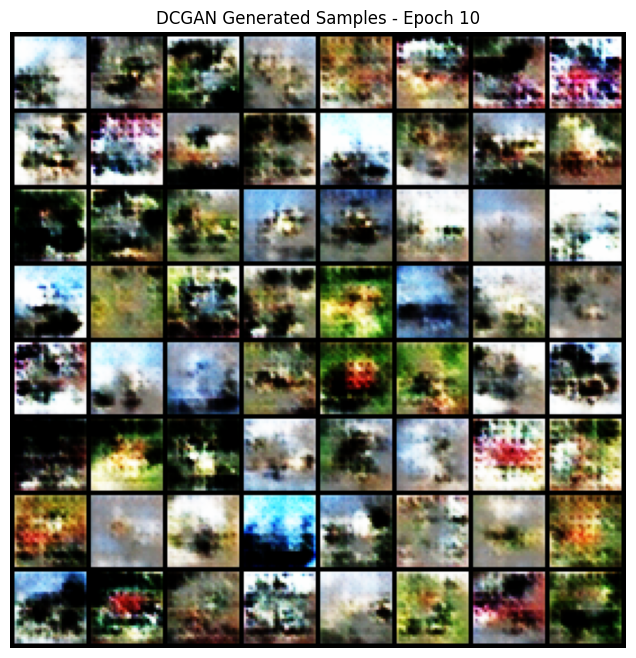

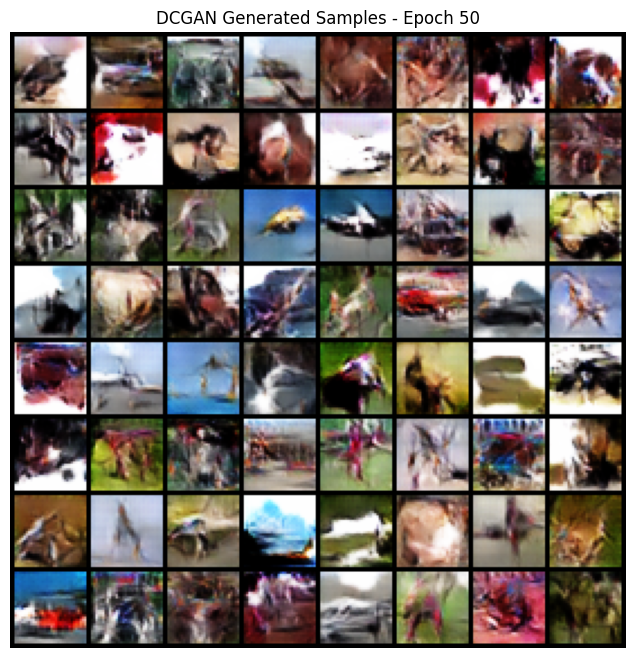

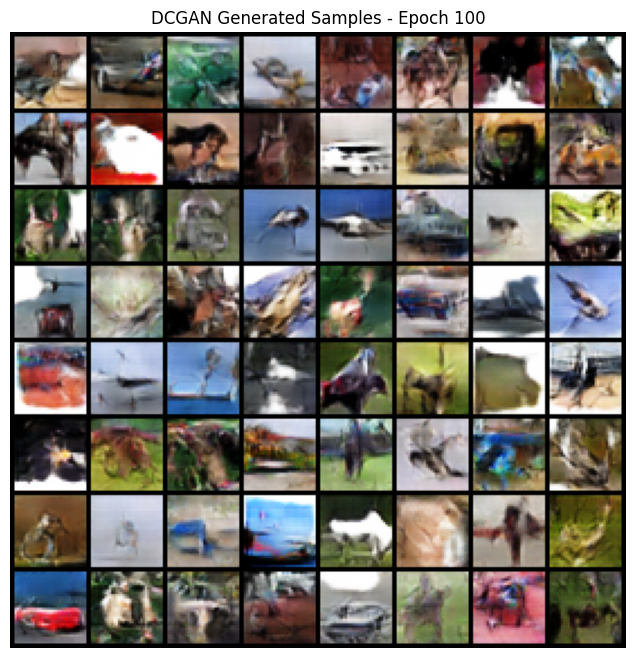

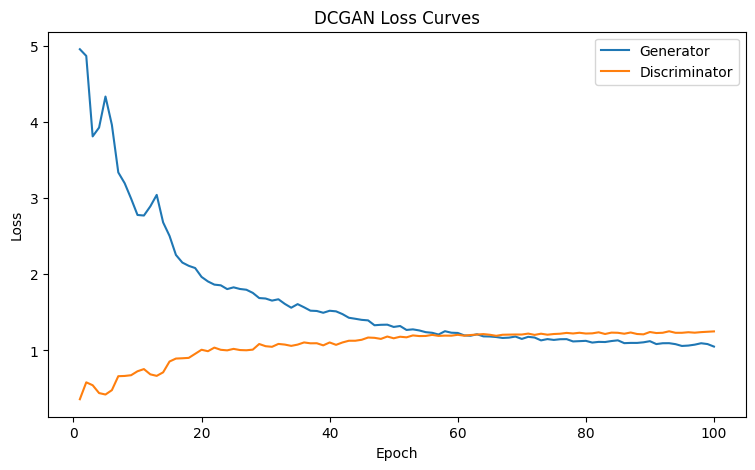

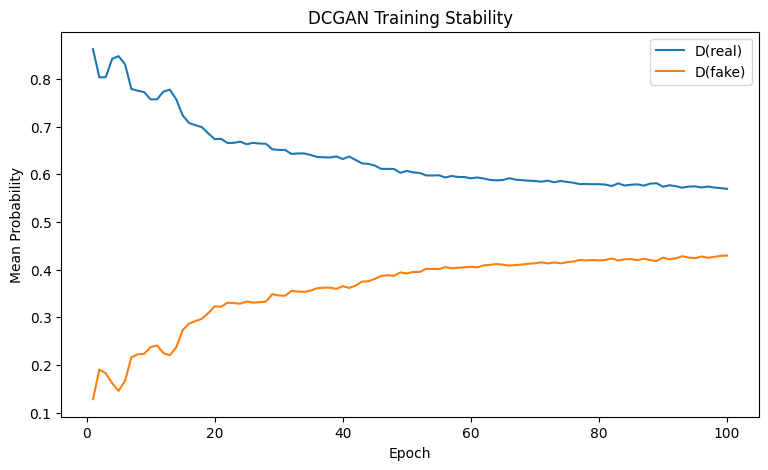

In [12]:
for epoch in DCGAN_CHECKPOINTS:

    show_samples(
        dcgan_snapshots[epoch],
        f"DCGAN Generated Samples - Epoch {epoch}"
    )


epochs = np.arange(
    1,
    DCGAN_EPOCHS + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    dcgan_history[
        "generator_loss"
    ],
    label="Generator"
)

plt.plot(
    epochs,
    dcgan_history[
        "discriminator_loss"
    ],
    label="Discriminator"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Loss Curves")
plt.legend()
plt.show()


plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    dcgan_history["d_real"],
    label="D(real)"
)

plt.plot(
    epochs,
    dcgan_history["d_fake"],
    label="D(fake)"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Probability")
plt.title("DCGAN Training Stability")
plt.legend()
plt.show()

In [13]:
def diversity_metrics(samples):

    samples = samples[:256]

    pixel_std = (
        samples
        .std(dim=0)
        .mean()
        .item()
    )

    small = F.interpolate(
        samples,
        size=(8, 8),
        mode="bilinear",
        align_corners=False
    )

    flat = small.flatten(1)

    pairwise_distance = (
        torch.pdist(
            flat,
            p=2
        )
        .mean()
        .item()
    )

    normalized = F.normalize(
        flat,
        dim=1
    )

    similarities = (
        normalized
        @ normalized.T
    )

    mask = torch.triu(
        torch.ones(
            similarities.shape,
            dtype=torch.bool
        ),
        diagonal=1
    )

    mean_similarity = (
        similarities[
            mask
        ]
        .mean()
        .item()
    )

    return {
        "Pixel Std":
            pixel_std,

        "Mean Pairwise Distance":
            pairwise_distance,

        "Mean Cosine Similarity":
            mean_similarity
    }

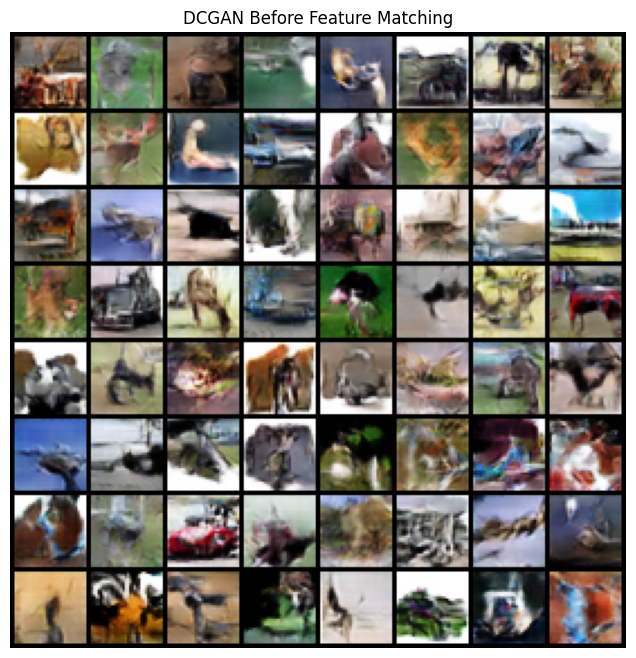

,Model,Pixel Std,Mean Pairwise Distance,Mean Cosine Similarity
0,Before Feature Matching,0.50012,9.193496,0.072287


In [14]:
before_fm_samples = (
    generate_samples(
        dcgan_generator,
        comparison_noise
    )
)

show_samples(
    before_fm_samples[:64],
    "DCGAN Before Feature Matching"
)

before_fm_metrics = (
    diversity_metrics(
        before_fm_samples
    )
)

pd.DataFrame([
    {
        "Model":
            "Before Feature Matching",
        **before_fm_metrics
    }
])

In [15]:
def train_feature_matching(
    generator,
    discriminator,
    loader,
    epochs=5,
    feature_weight=10.0
):

    generator = generator.to(device)
    discriminator = discriminator.to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_g = torch.optim.Adam(
        generator.parameters(),
        lr=0.0001,
        betas=(0.5, 0.999)
    )

    optimizer_d = torch.optim.Adam(
        discriminator.parameters(),
        lr=0.0001,
        betas=(0.5, 0.999)
    )

    history = {
        "generator_loss": [],
        "discriminator_loss": [],
        "feature_loss": []
    }

    for epoch in range(
        1,
        epochs + 1
    ):

        g_losses = []
        d_losses = []
        feature_losses = []

        for real, _ in loader:

            real = real.to(
                device,
                non_blocking=True
            )

            batch_size = real.size(0)

            ones = torch.ones(
                batch_size,
                device=device
            )

            zeros = torch.zeros(
                batch_size,
                device=device
            )

            discriminator.train()

            set_requires_grad(
                discriminator,
                True
            )

            optimizer_d.zero_grad(
                set_to_none=True
            )

            noise = torch.randn(
                batch_size,
                LATENT_DIM,
                1,
                1,
                device=device
            )

            fake = generator(
                noise
            )

            real_output = discriminator(
                real
            )

            fake_output = discriminator(
                fake.detach()
            )

            loss_d = (
                criterion(
                    real_output,
                    ones
                )
                +
                criterion(
                    fake_output,
                    zeros
                )
            )

            loss_d.backward()

            optimizer_d.step()

            discriminator.eval()

            set_requires_grad(
                discriminator,
                False
            )

            optimizer_g.zero_grad(
                set_to_none=True
            )

            with torch.no_grad():

                _, real_features = (
                    discriminator(
                        real,
                        return_features=True
                    )
                )

            noise = torch.randn(
                batch_size,
                LATENT_DIM,
                1,
                1,
                device=device
            )

            fake = generator(
                noise
            )

            (
                fake_output,
                fake_features
            ) = discriminator(
                fake,
                return_features=True
            )

            adversarial_loss = (
                criterion(
                    fake_output,
                    ones
                )
            )

            feature_loss = F.mse_loss(
                fake_features.mean(
                    dim=0
                ),
                real_features.mean(
                    dim=0
                )
            )

            loss_g = (
                adversarial_loss
                +
                feature_weight
                * feature_loss
            )

            loss_g.backward()

            optimizer_g.step()

            set_requires_grad(
                discriminator,
                True
            )

            g_losses.append(
                loss_g.item()
            )

            d_losses.append(
                loss_d.item()
            )

            feature_losses.append(
                feature_loss.item()
            )

        history[
            "generator_loss"
        ].append(
            np.mean(g_losses)
        )

        history[
            "discriminator_loss"
        ].append(
            np.mean(d_losses)
        )

        history[
            "feature_loss"
        ].append(
            np.mean(
                feature_losses
            )
        )

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"G {history['generator_loss'][-1]:.4f} | "
            f"D {history['discriminator_loss'][-1]:.4f} | "
            f"FM {history['feature_loss'][-1]:.4f}"
        )

    return (
        generator,
        discriminator,
        history
    )

Epoch 01/5 | G 1.0087 | D 0.6165 | FM 0.0060
Epoch 02/5 | G 1.0133 | D 0.4379 | FM 0.0064
Epoch 03/5 | G 1.0230 | D 0.3497 | FM 0.0054
Epoch 04/5 | G 1.0029 | D 0.2016 | FM 0.0069
Epoch 05/5 | G 0.9265 | D 0.0753 | FM 0.0086


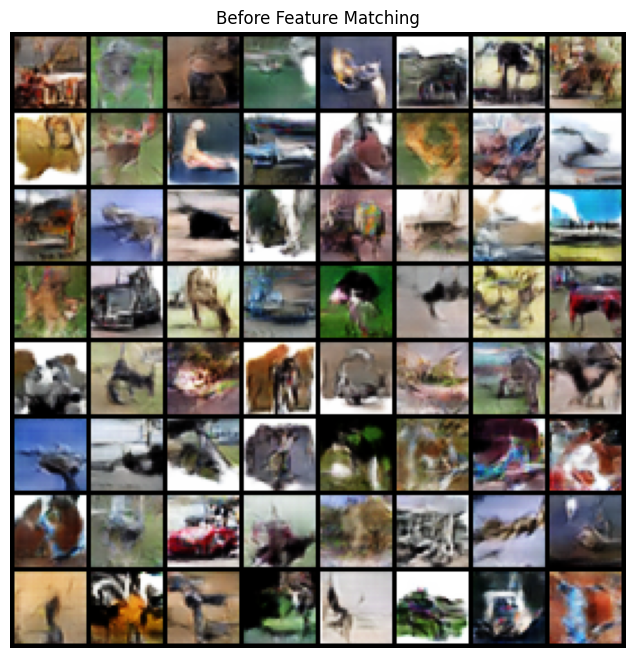

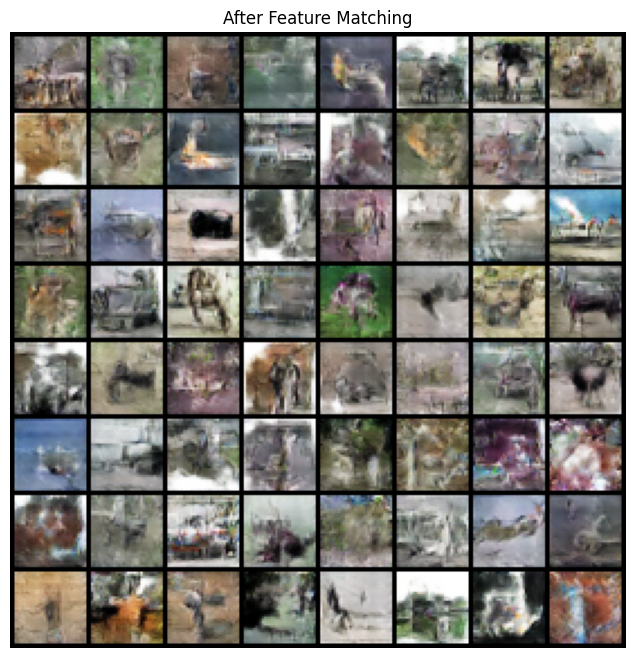

,Model,Pixel Std,Mean Pairwise Distance,Mean Cosine Similarity
0,Before Feature Matching,0.500120,9.193496,0.072287
1,After Feature Matching,0.379152,6.798036,0.054089


In [16]:
fm_generator = copy.deepcopy(
    dcgan_generator
)

fm_discriminator = copy.deepcopy(
    dcgan_discriminator
)

(
    fm_generator,
    fm_discriminator,
    fm_history
) = train_feature_matching(
    fm_generator,
    fm_discriminator,
    train_loader,
    epochs=FM_EPOCHS,
    feature_weight=10.0
)

after_fm_samples = (
    generate_samples(
        fm_generator,
        comparison_noise
    )
)

show_samples(
    before_fm_samples[:64],
    "Before Feature Matching"
)

show_samples(
    after_fm_samples[:64],
    "After Feature Matching"
)

after_fm_metrics = (
    diversity_metrics(
        after_fm_samples
    )
)

diversity_comparison = pd.DataFrame([
    {
        "Model":
            "Before Feature Matching",
        **before_fm_metrics
    },
    {
        "Model":
            "After Feature Matching",
        **after_fm_metrics
    }
])

diversity_comparison

In [17]:
diversity_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "diversity_comparison.csv"
    ),
    index=False
)

save_samples(
    before_fm_samples[:64],
    "before_feature_matching.png"
)

save_samples(
    after_fm_samples[:64],
    "after_feature_matching.png"
)

torch.save(
    copy_state(
        fm_generator
    ),
    os.path.join(
        OUTPUT_DIR,
        "feature_matching_generator.pt"
    )
)

del fm_discriminator

torch.cuda.empty_cache()

In [18]:
def gradient_penalty(
    critic,
    real,
    fake
):

    batch_size = real.size(0)

    alpha = torch.rand(
        batch_size,
        1,
        1,
        1,
        device=device
    )

    interpolated = (
        alpha * real
        +
        (1 - alpha) * fake
    )

    interpolated.requires_grad_(
        True
    )

    scores = critic(
        interpolated
    )

    gradients = torch.autograd.grad(
        outputs=scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(
            scores
        ),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.reshape(
        batch_size,
        -1
    )

    return (
        (
            gradients.norm(
                2,
                dim=1
            )
            - 1
        ) ** 2
    ).mean()


def train_wgan_gp(
    generator,
    critic,
    loader,
    epochs,
    lambda_gp=10.0,
    n_critic=1
):

    generator = generator.to(device)
    critic = critic.to(device)

    optimizer_g = torch.optim.Adam(
        generator.parameters(),
        lr=0.0001,
        betas=(0.0, 0.9)
    )

    optimizer_c = torch.optim.Adam(
        critic.parameters(),
        lr=0.0001,
        betas=(0.0, 0.9)
    )

    history = {
        "generator_loss": [],
        "critic_loss": [],
        "gradient_penalty": [],
        "wasserstein_gap": [],
        "epoch_time": [],
        "cumulative_time": []
    }

    snapshots = {}
    checkpoints = {}

    total_start = time.perf_counter()

    for epoch in range(
        1,
        epochs + 1
    ):

        generator.train()
        critic.train()

        g_losses = []
        c_losses = []
        gp_values = []
        gaps = []

        epoch_start = time.perf_counter()

        for real, _ in loader:

            real = real.to(
                device,
                non_blocking=True
            )

            batch_size = real.size(0)

            for _ in range(n_critic):

                noise = torch.randn(
                    batch_size,
                    LATENT_DIM,
                    1,
                    1,
                    device=device
                )

                with torch.no_grad():
                    fake = generator(
                        noise
                    )

                optimizer_c.zero_grad(
                    set_to_none=True
                )

                real_score = (
                    critic(real).mean()
                )

                fake_score = (
                    critic(fake).mean()
                )

                gp = gradient_penalty(
                    critic,
                    real,
                    fake
                )

                loss_c = (
                    fake_score
                    - real_score
                    + lambda_gp * gp
                )

                loss_c.backward()

                optimizer_c.step()

            optimizer_g.zero_grad(
                set_to_none=True
            )

            noise = torch.randn(
                batch_size,
                LATENT_DIM,
                1,
                1,
                device=device
            )

            fake = generator(noise)

            loss_g = (
                -critic(fake).mean()
            )

            loss_g.backward()

            optimizer_g.step()

            g_losses.append(
                loss_g.item()
            )

            c_losses.append(
                loss_c.item()
            )

            gp_values.append(
                gp.item()
            )

            gaps.append(
                (
                    real_score
                    - fake_score
                ).item()
            )

        elapsed = (
            time.perf_counter()
            - epoch_start
        )

        cumulative = (
            time.perf_counter()
            - total_start
        )

        history[
            "generator_loss"
        ].append(
            np.mean(g_losses)
        )

        history[
            "critic_loss"
        ].append(
            np.mean(c_losses)
        )

        history[
            "gradient_penalty"
        ].append(
            np.mean(gp_values)
        )

        history[
            "wasserstein_gap"
        ].append(
            np.mean(gaps)
        )

        history[
            "epoch_time"
        ].append(elapsed)

        history[
            "cumulative_time"
        ].append(cumulative)

        if epoch in WGAN_CHECKPOINTS:

            samples = generate_samples(
                generator,
                fixed_noise
            )

            snapshots[epoch] = samples

            state = copy_state(
                generator
            )

            checkpoints[epoch] = state

            torch.save(
                state,
                os.path.join(
                    OUTPUT_DIR,
                    f"wgan_gp_epoch_{epoch}.pt"
                )
            )

            save_samples(
                samples,
                f"wgan_gp_epoch_{epoch}.png"
            )

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"G {history['generator_loss'][-1]:.4f} | "
            f"C {history['critic_loss'][-1]:.4f} | "
            f"GP {history['gradient_penalty'][-1]:.4f} | "
            f"time {elapsed:.1f}s"
        )

    total_time = (
        time.perf_counter()
        - total_start
    )

    return (
        generator,
        critic,
        history,
        snapshots,
        checkpoints,
        total_time
    )

In [19]:
set_seed()

wgan_generator = Generator(
    LATENT_DIM
)

wgan_critic = Critic()

initialize_weights(
    wgan_generator
)

initialize_weights(
    wgan_critic
)

print(
    "WGAN Generator parameters:",
    count_parameters(
        wgan_generator
    )
)

print(
    "Critic parameters:",
    count_parameters(
        wgan_critic
    )
)

(
    wgan_generator,
    wgan_critic,
    wgan_history,
    wgan_snapshots,
    wgan_checkpoints,
    wgan_total_time
) = train_wgan_gp(
    wgan_generator,
    wgan_critic,
    train_loader,
    epochs=WGAN_EPOCHS,
    lambda_gp=10.0,
    n_critic=1
)

pd.DataFrame(
    wgan_history
).to_csv(
    os.path.join(
        OUTPUT_DIR,
        "wgan_gp_history.csv"
    ),
    index=False
)

print(
    "WGAN-GP total training time:",
    round(
        wgan_total_time / 60,
        2
    ),
    "minutes"
)

WGAN Generator parameters: 1068928
Critic parameters: 662977
Epoch 001/30 | G -8.7358 | C -1.5362 | GP 0.1961 | time 17.8s
Epoch 002/30 | G -5.7519 | C 1.5655 | GP 0.0653 | time 17.3s
Epoch 003/30 | G -4.2079 | C 0.5853 | GP 0.0399 | time 17.2s
Epoch 004/30 | G -1.1628 | C 1.0101 | GP 0.0617 | time 17.6s
Epoch 005/30 | G 1.6915 | C 1.9200 | GP 0.0613 | time 16.9s
Epoch 006/30 | G 5.2532 | C 2.1405 | GP 0.0609 | time 17.0s
Epoch 007/30 | G 8.8325 | C 1.7255 | GP 0.0469 | time 17.1s
Epoch 008/30 | G 12.4313 | C 1.1672 | GP 0.0342 | time 16.8s
Epoch 009/30 | G 13.9978 | C 0.7747 | GP 0.0212 | time 17.7s
Epoch 010/30 | G 14.9002 | C 0.4922 | GP 0.0154 | time 17.4s
Epoch 011/30 | G 15.4727 | C 0.2912 | GP 0.0133 | time 16.8s
Epoch 012/30 | G 15.0897 | C 0.4096 | GP 0.0111 | time 16.9s
Epoch 013/30 | G 17.3251 | C 0.3747 | GP 0.0091 | time 17.0s
Epoch 014/30 | G 19.1494 | C 0.1638 | GP 0.0089 | time 16.9s
Epoch 015/30 | G 19.1840 | C 0.0228 | GP 0.0082 | time 17.6s
Epoch 016/30 | G 19.2441 |

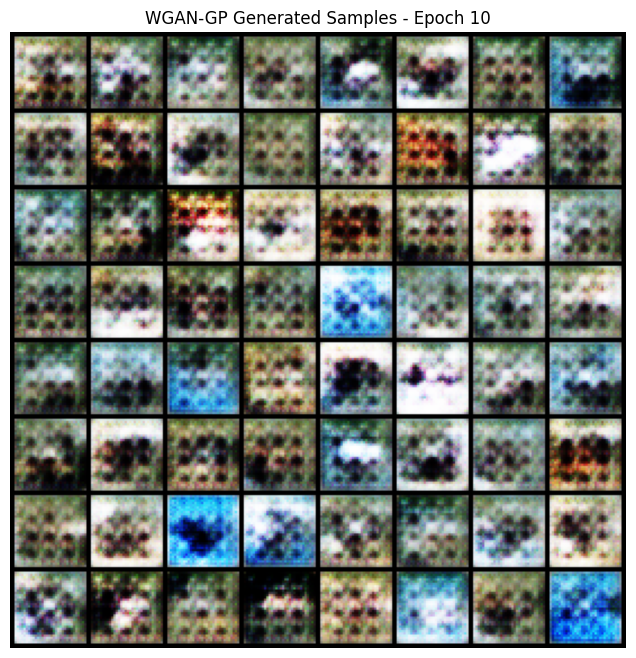

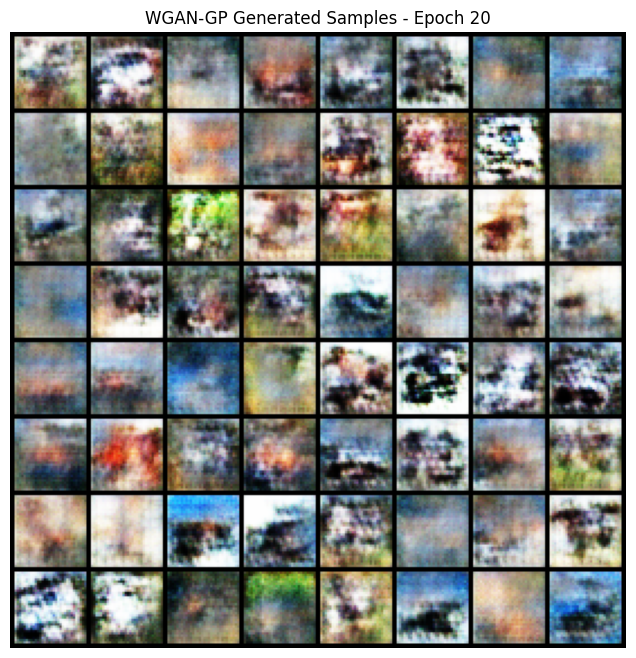

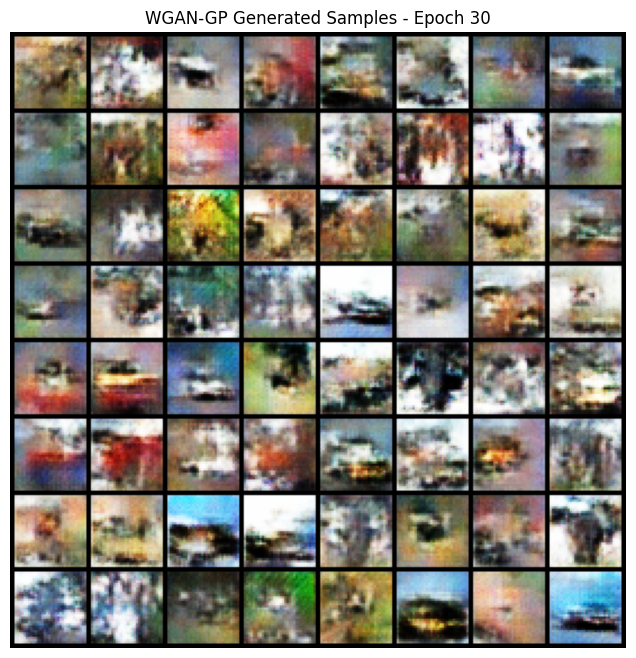

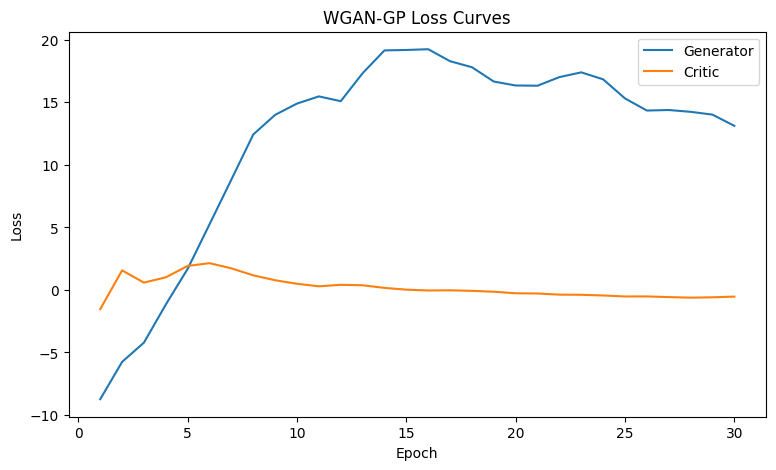

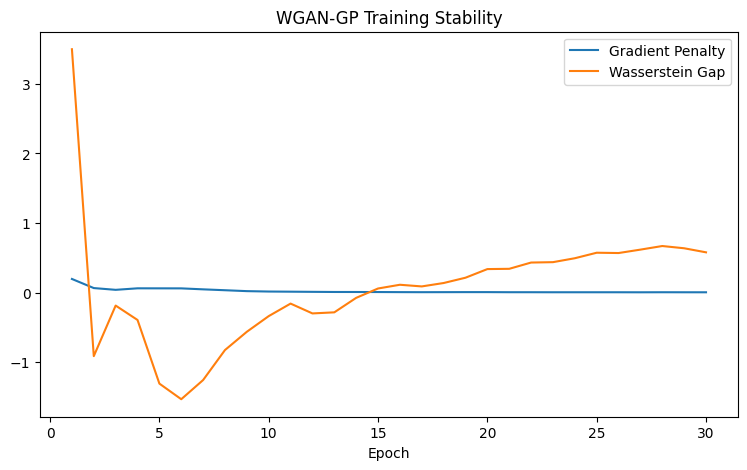

In [20]:
for epoch in WGAN_CHECKPOINTS:

    show_samples(
        wgan_snapshots[epoch],
        f"WGAN-GP Generated Samples - Epoch {epoch}"
    )


wgan_epochs = np.arange(
    1,
    WGAN_EPOCHS + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    wgan_epochs,
    wgan_history[
        "generator_loss"
    ],
    label="Generator"
)

plt.plot(
    wgan_epochs,
    wgan_history[
        "critic_loss"
    ],
    label="Critic"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN-GP Loss Curves")
plt.legend()
plt.show()


plt.figure(figsize=(9, 5))

plt.plot(
    wgan_epochs,
    wgan_history[
        "gradient_penalty"
    ],
    label="Gradient Penalty"
)

plt.plot(
    wgan_epochs,
    wgan_history[
        "wasserstein_gap"
    ],
    label="Wasserstein Gap"
)

plt.xlabel("Epoch")
plt.title("WGAN-GP Training Stability")
plt.legend()
plt.show()

In [21]:
def to_fid_range(images):

    return (
        (images + 1) / 2
    ).clamp(0, 1)


def prepare_real_fid(
    metric,
    loader,
    n_samples
):

    count = 0

    with torch.no_grad():

        for real, _ in loader:

            if count >= n_samples:
                break

            remaining = (
                n_samples - count
            )

            real = real[
                :remaining
            ].to(
                device,
                non_blocking=True
            )

            metric.update(
                to_fid_range(real),
                real=True
            )

            count += real.size(0)


def fid_for_generator(
    generator,
    metric,
    n_samples
):

    metric.reset()

    generator.eval()

    count = 0

    with torch.no_grad():

        while count < n_samples:

            current = min(
                BATCH_SIZE,
                n_samples - count
            )

            noise = torch.randn(
                current,
                LATENT_DIM,
                1,
                1,
                device=device
            )

            fake = generator(
                noise
            )

            metric.update(
                to_fid_range(fake),
                real=False
            )

            count += current

    return metric.compute().item()


def generator_from_state(state):

    model = Generator(
        LATENT_DIM
    ).to(device)

    model.load_state_dict(
        state
    )

    return model

In [22]:
fid_metric = FrechetInceptionDistance(
    feature=2048,
    normalize=True,
    reset_real_features=False
).to(device)

prepare_real_fid(
    fid_metric,
    fid_loader,
    FID_SAMPLES
)

fid_rows = []

for epoch in DCGAN_CHECKPOINTS:

    model = generator_from_state(
        dcgan_checkpoints[epoch]
    )

    score = fid_for_generator(
        model,
        fid_metric,
        FID_SAMPLES
    )

    fid_rows.append({
        "Model": "DCGAN",
        "Epoch": epoch,
        "Training Minutes":
            dcgan_history[
                "cumulative_time"
            ][epoch - 1] / 60,
        "FID": score
    })

    del model

    torch.cuda.empty_cache()


for epoch in WGAN_CHECKPOINTS:

    model = generator_from_state(
        wgan_checkpoints[epoch]
    )

    score = fid_for_generator(
        model,
        fid_metric,
        FID_SAMPLES
    )

    fid_rows.append({
        "Model": "WGAN-GP",
        "Epoch": epoch,
        "Training Minutes":
            wgan_history[
                "cumulative_time"
            ][epoch - 1] / 60,
        "FID": score
    })

    del model

    torch.cuda.empty_cache()


fid_results = pd.DataFrame(
    fid_rows
)

fid_results

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 152MB/s]


,Model,Epoch,Training Minutes,FID
0,DCGAN,10,2.228030,151.802063
1,DCGAN,50,10.894854,85.564095
2,DCGAN,100,21.677964,68.649940
3,WGAN-GP,10,2.882213,320.537903
4,WGAN-GP,20,5.714775,210.290939
5,WGAN-GP,30,8.552351,164.105850


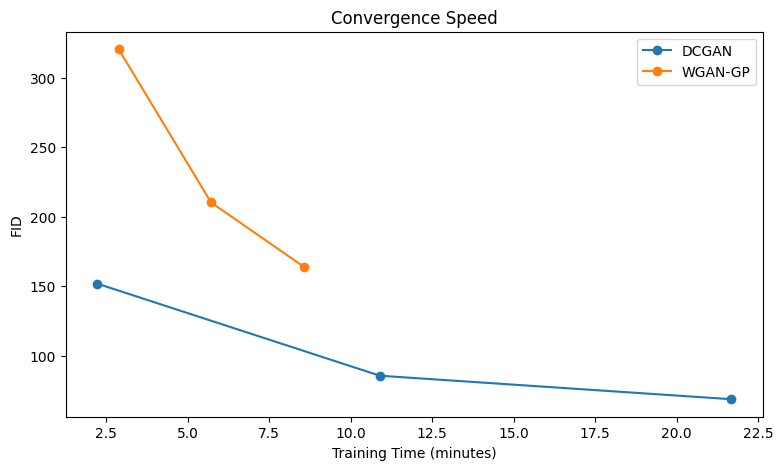

In [23]:
fid_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "fid_results.csv"
    ),
    index=False
)

plt.figure(figsize=(9, 5))

for model_name in [
    "DCGAN",
    "WGAN-GP"
]:

    data = fid_results[
        fid_results[
            "Model"
        ] == model_name
    ]

    plt.plot(
        data[
            "Training Minutes"
        ],
        data["FID"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training Time (minutes)")
plt.ylabel("FID")
plt.title("Convergence Speed")
plt.legend()
plt.show()

In [24]:
def relative_loss_variation(
    values,
    last_n=10
):

    values = np.array(
        values[-last_n:]
    )

    changes = np.abs(
        np.diff(values)
    ).mean()

    scale = (
        np.abs(values).mean()
        + 1e-8
    )

    return changes / scale


dcgan_final_fid = (
    fid_results[
        (
            fid_results["Model"]
            == "DCGAN"
        )
        &
        (
            fid_results["Epoch"]
            == 100
        )
    ]["FID"].iloc[0]
)

wgan_final_fid = (
    fid_results[
        (
            fid_results["Model"]
            == "WGAN-GP"
        )
        &
        (
            fid_results["Epoch"]
            == WGAN_EPOCHS
        )
    ]["FID"].iloc[0]
)


comparison_results = pd.DataFrame([
    {
        "Model": "DCGAN",
        "Epochs": DCGAN_EPOCHS,
        "Final FID":
            dcgan_final_fid,
        "Average Epoch Time":
            np.mean(
                dcgan_history[
                    "epoch_time"
                ]
            ),
        "Total Training Minutes":
            dcgan_total_time / 60,
        "Generator Loss Variation":
            relative_loss_variation(
                dcgan_history[
                    "generator_loss"
                ]
            ),
        "Adversary Loss Variation":
            relative_loss_variation(
                dcgan_history[
                    "discriminator_loss"
                ]
            )
    },

    {
        "Model": "WGAN-GP",
        "Epochs": WGAN_EPOCHS,
        "Final FID":
            wgan_final_fid,
        "Average Epoch Time":
            np.mean(
                wgan_history[
                    "epoch_time"
                ]
            ),
        "Total Training Minutes":
            wgan_total_time / 60,
        "Generator Loss Variation":
            relative_loss_variation(
                wgan_history[
                    "generator_loss"
                ]
            ),
        "Adversary Loss Variation":
            relative_loss_variation(
                wgan_history[
                    "critic_loss"
                ]
            )
    }
])

comparison_results

,Model,Epochs,Final FID,Average Epoch Time,Total Training Minutes,Generator Loss Variation,Adversary Loss Variation
0,DCGAN,100,68.64994,13.000161,21.679097,0.013170,0.006608
1,WGAN-GP,30,164.10585,17.100573,8.553563,0.039407,0.097123


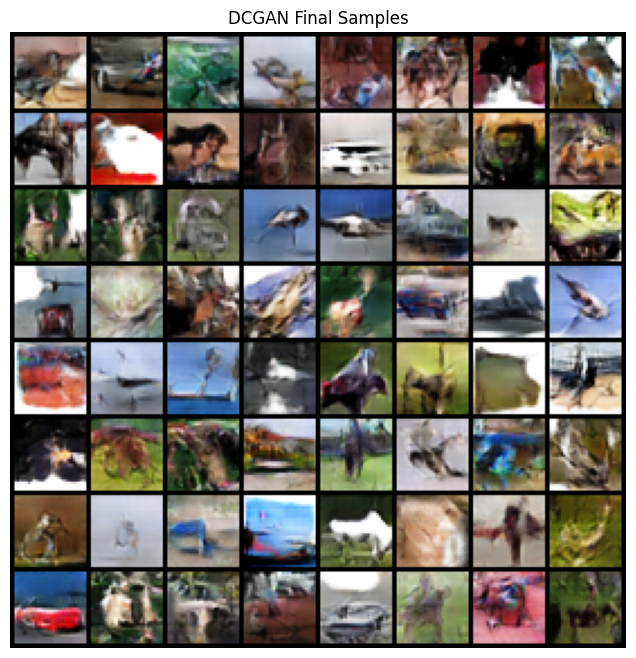

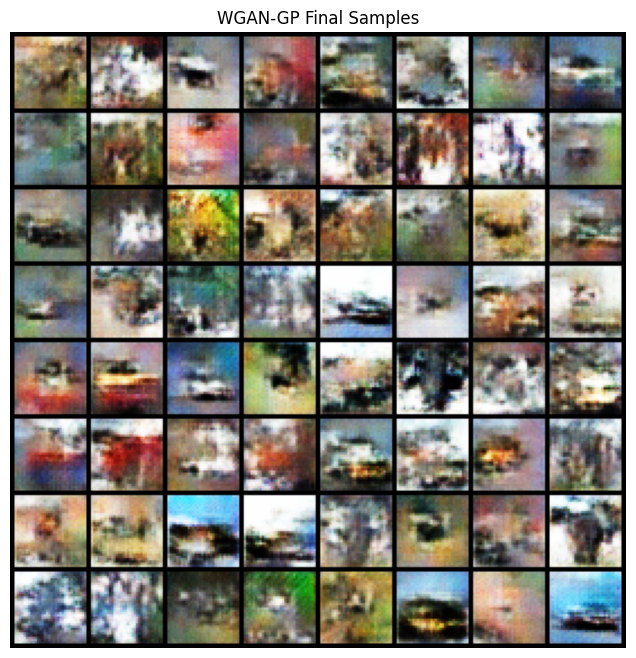

All important results saved in:
/content/drive/MyDrive/dl_pset4_results


In [25]:
comparison_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_comparison.csv"
    ),
    index=False
)

final_dcgan_samples = (
    generate_samples(
        dcgan_generator,
        fixed_noise
    )
)

final_wgan_samples = (
    generate_samples(
        wgan_generator,
        fixed_noise
    )
)

show_samples(
    final_dcgan_samples,
    "DCGAN Final Samples"
)

show_samples(
    final_wgan_samples,
    "WGAN-GP Final Samples"
)

save_samples(
    final_dcgan_samples,
    "dcgan_final_samples.png"
)

save_samples(
    final_wgan_samples,
    "wgan_gp_final_samples.png"
)

print(
    "All important results saved in:"
)

print(
    OUTPUT_DIR
)